<a href="https://colab.research.google.com/github/nirupamgpta/Assignments/blob/main/Copy_of_NG_Lecture_1_tutorial_classification_task_tutorial_and_DIY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction using scikit-learn #

![breast cancer detection image](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-57740-5/MediaObjects/41598_2024_57740_Fig1_HTML.png)

Problem - Breast cancer prediction is a binary classification problem where the goal is to determine whether a tumor is malignant (cancerous) or benign (non-cancerous) based on measurable characteristics of cell nuclei obtained from medical imaging or biopsies.


sklearn datasets - https://scikit-learn.org/stable/api/sklearn.datasets.html

## Import required libraries ##

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading the breast cancer data ##

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape:", X.shape)

Shape: (569, 30)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Part-1 : Classification using Logistic Regression ##

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support


Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



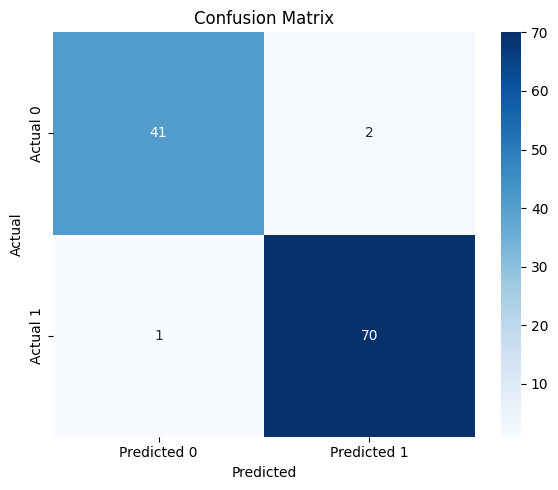

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Do-It-Yourself (DIY) ##

So far, we explored Logistic Regression. It assumes linear decision boundary and simple relationships.

But real-world data is often Non-linear, Noisy and Complex

This raises a question: Can we build better classifiers using other algorithms?

## Part - 2 (DIY) ##

Lets explore how we can implement the other ML Classification algorithms, namely

  1. K-Nearest Neighbors - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
  2. Decision Tree Classifier - https://scikit-learn.org/stable/modules/tree.html
  3. Support Vector Machines - https://scikit-learn.org/stable/modules/svm.html




## Part - 2a : KNN ##

In [ ]:
# TODO: Import KNN
from sklearn.neighbors import KNeighborsClassifier
knn = None # TODO: Initialize model


In [ ]:
# TODO: Train model
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [ ]:
# TODO: Predict and evaluate
predictions = knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print(classification_report(y_test, predictions, target_names=data.target_names))

Accuracy: 0.96
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



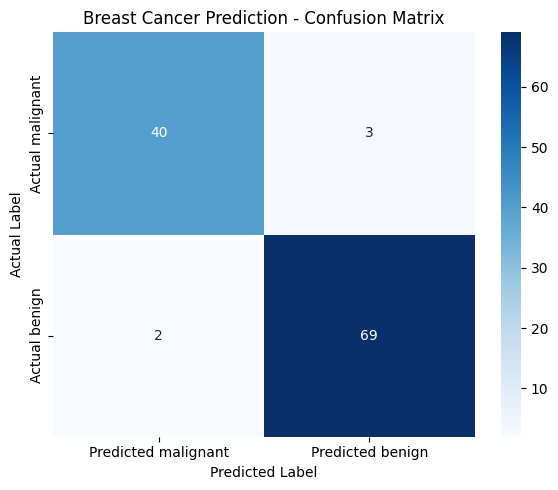

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix using your model's predictions
# 'predictions' comes from the previous KNN code snippet
cm = confusion_matrix(y_test, predictions)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Predicted {name}' for name in data.target_names],
    yticklabels=[f'Actual {name}' for name in data.target_names]
)

plt.title('Breast Cancer Prediction - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Part - 2b : Decision Tree Classifier ##

In [ ]:
# TODO: Import Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = None  # TODO: Initialize model

In [ ]:
# TODO: Train model
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# TODO: Predict and evaluate
predictions = dt_classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}\n")
print(classification_report(y_test, predictions, target_names=data.target_names))


Accuracy: 0.95

              precision    recall  f1-score   support

   malignant       0.95      0.91      0.93        43
      benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



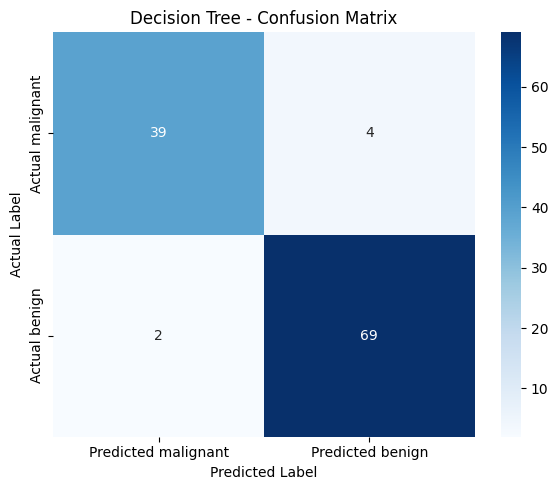

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Predicted {name}" for name in data.target_names],
    yticklabels=[f"Actual {name}" for name in data.target_names],
)
plt.title("Decision Tree - Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

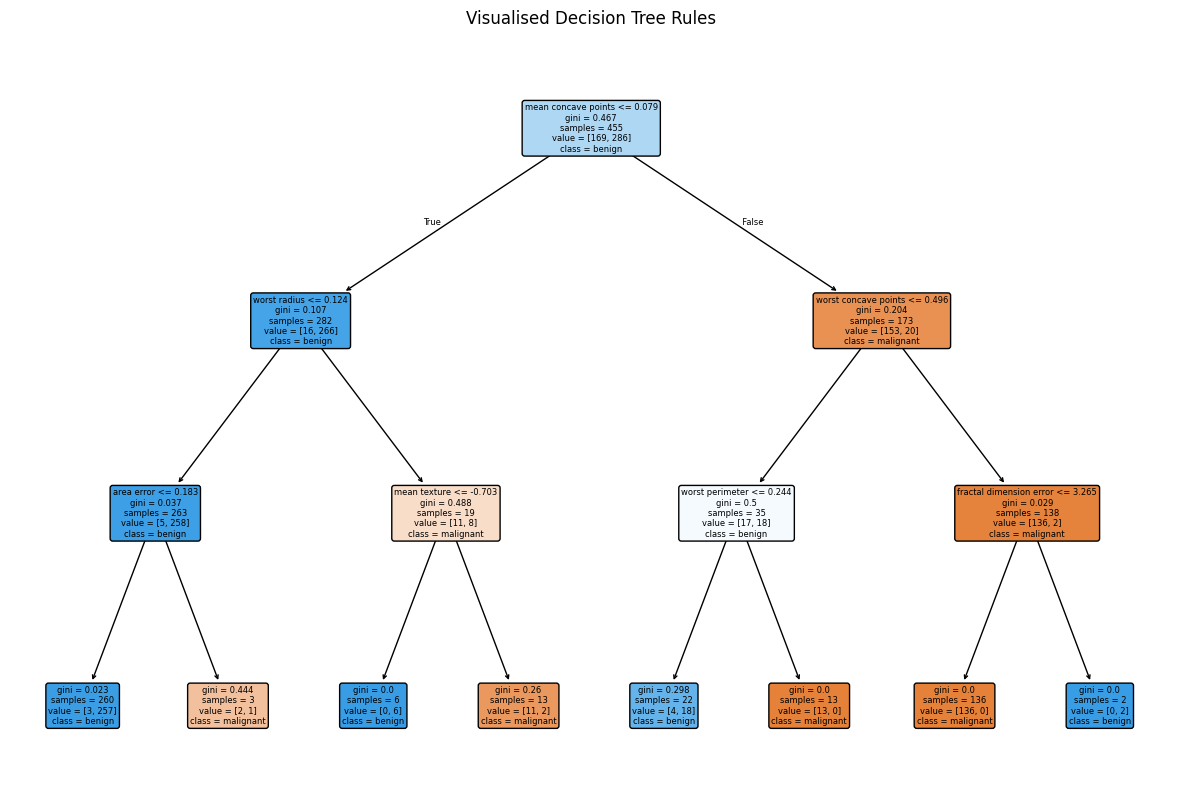

In [ ]:
plt.figure(figsize=(15, 10))
plot_tree(
    dt_classifier,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
)
plt.title("Visualised Decision Tree Rules")
plt.show()

## Part - 2c : SVM ##

In [ ]:
# TODO: Import SVM
from sklearn.svm import SVC
svm = None  # TODO: Initialize model

In [ ]:
# TODO: Train model
svm_classifier = SVC(kernel="rbf", C=1.0, random_state=42)
svm_classifier.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
# TODO: Predict and evaluate
predictions = svm_classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}\n")
print(classification_report(y_test, predictions, target_names=data.target_names))


Accuracy: 0.98

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



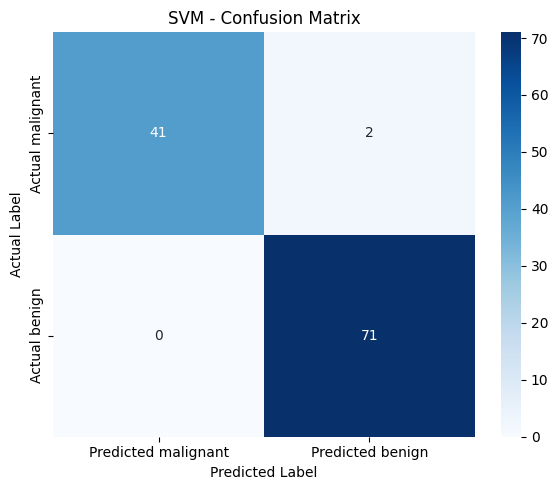

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Predicted {name}" for name in data.target_names],
    yticklabels=[f"Actual {name}" for name in data.target_names],
)
plt.title("SVM - Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()